In [314]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import joblib

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [315]:
df = pd.read_csv("../data/car_data.csv", sep=",")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [316]:
df.shape

(301, 9)

In [317]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [318]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [319]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [320]:
df.duplicated().sum()

np.int64(2)

In [321]:
df.drop_duplicates(inplace=True)

In [322]:
df["Fuel_Type"].unique()

<ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [323]:
df["Transmission"].unique()

<ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [324]:
df["Selling_type"].unique()

<ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str

In [325]:
df["Profit"] = df["Present_Price"] - df["Selling_Price"]

In [326]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Profit
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2.24
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,4.79
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2.60
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,1.30
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2.27


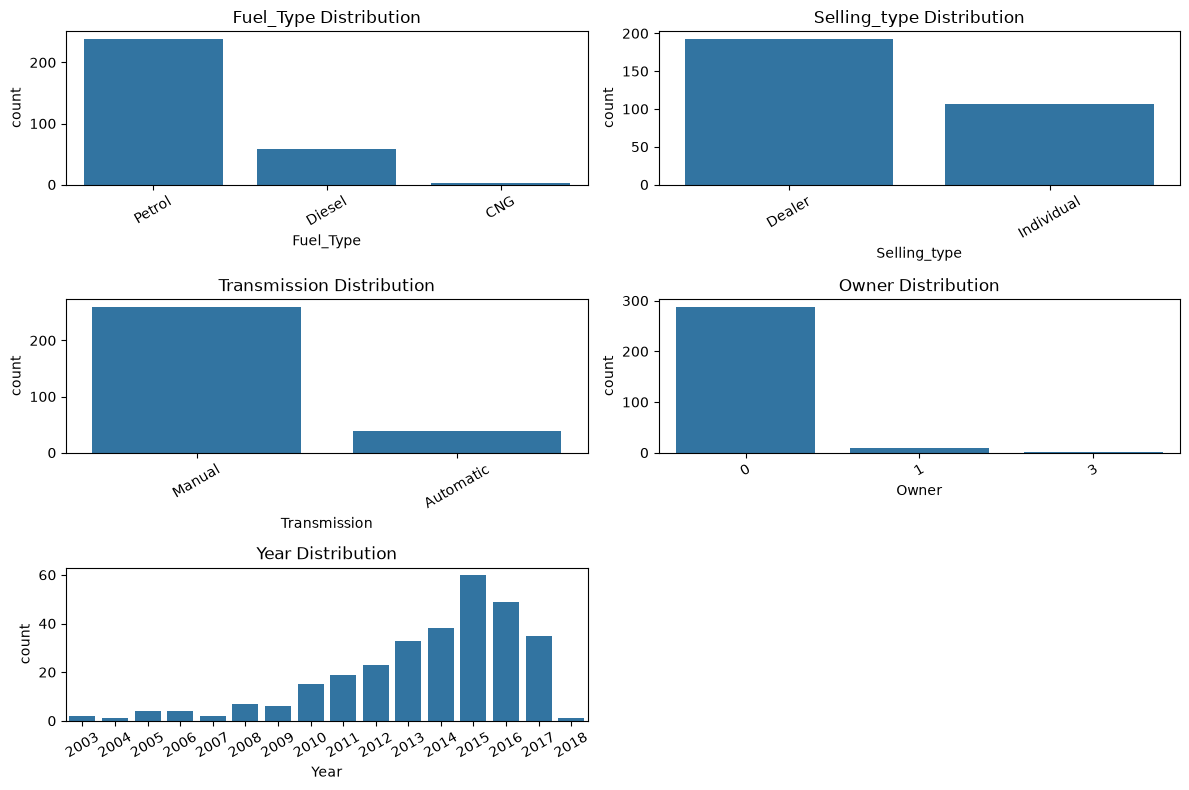

In [327]:
cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Year']

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()  # Convert 2D array to 1D

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation=30)
    
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [328]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

num_cols

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner',
       'Profit'],
      dtype='str')

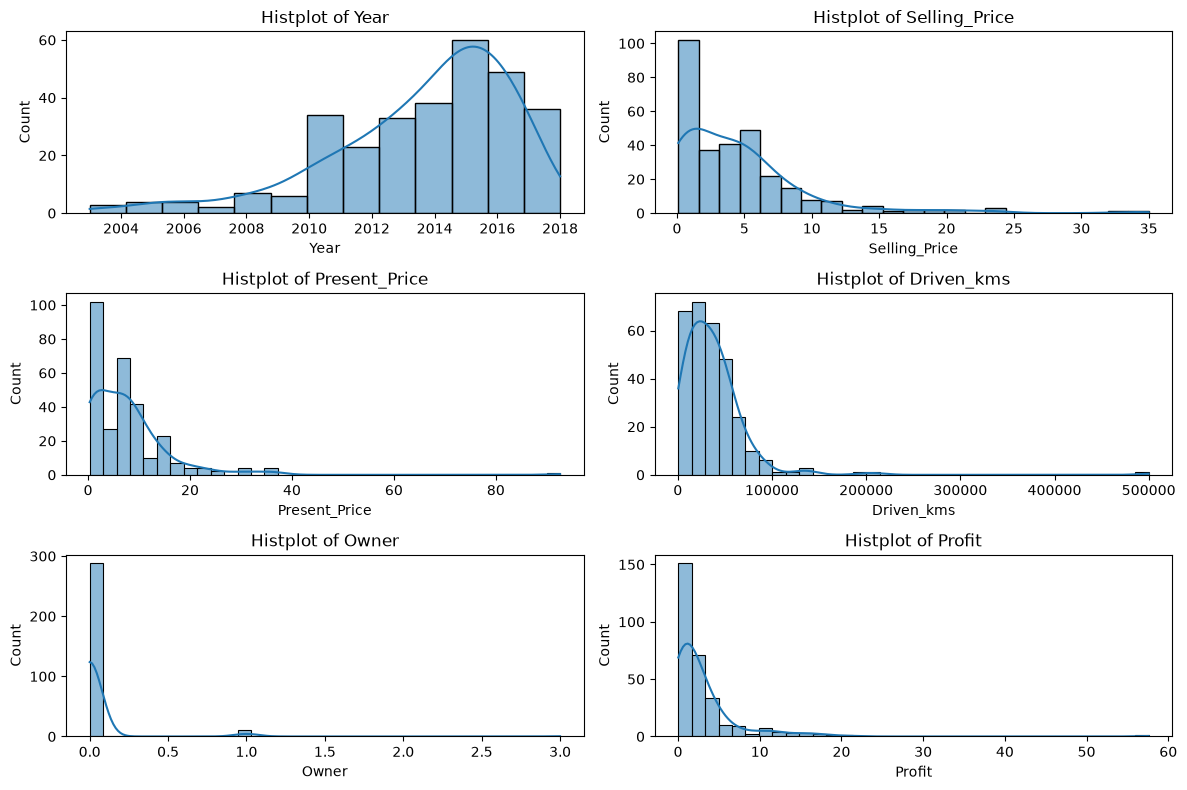

In [329]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()  # Convert 2D array to 1D

for i, col in enumerate(num_cols):
    sns.histplot(x=col, data=df, ax=axes[i], kde=True)
    axes[i].set_title(f"Histplot of {col}")
    
plt.tight_layout()
plt.show()

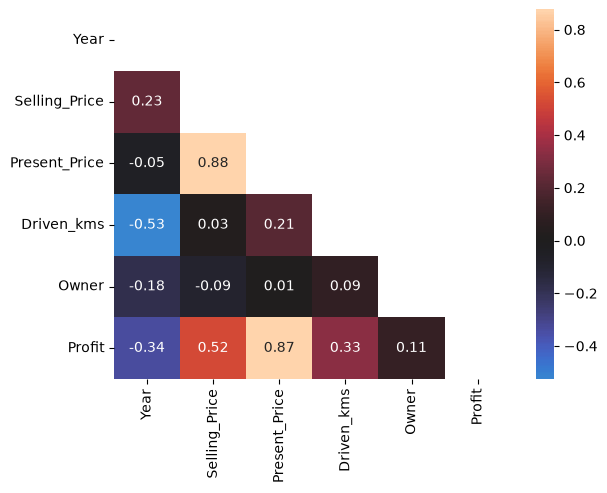

In [330]:
from wcwidth import center


corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    center= 0,
    annot=True,
    fmt='.2f',
)

plt.show()

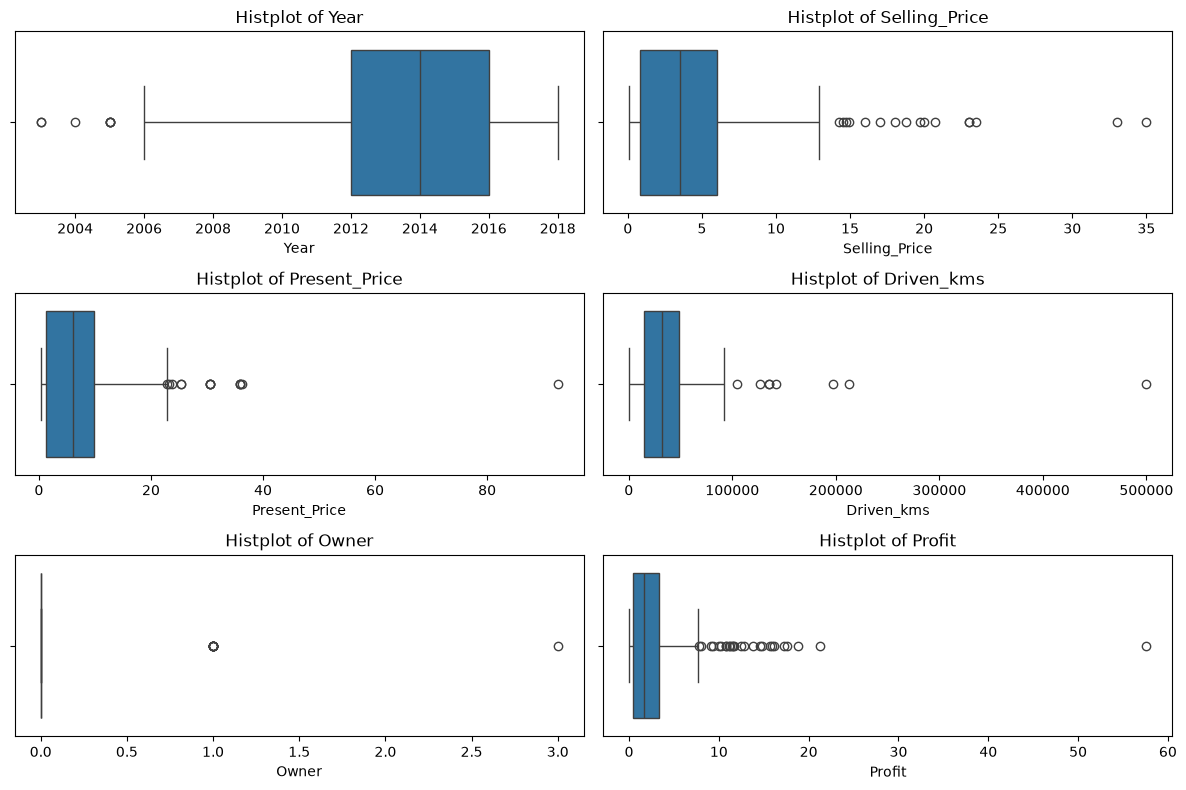

In [331]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()  # Convert 2D array to 1D

for i, col in enumerate(num_cols):
    sns.boxplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"Histplot of {col}")
    
plt.tight_layout()
plt.show()

In [332]:
### Data transformation as skewness is seen


In [333]:
from scipy.stats import skew

for i in num_cols:
    print(f"Before transformation for {i} : {df[i].skew()}")
    print(f"After transformation for {i} : {np.log1p(df[i]).skew()} \n\n")

Before transformation for Year : -1.2368759011840527
After transformation for Year : -1.241099856091716 


Before transformation for Selling_Price : 2.536521826497541
After transformation for Selling_Price : 0.1107840112840907 


Before transformation for Present_Price : 4.18925490207532
After transformation for Present_Price : -0.04643643605976825 


Before transformation for Driven_kms : 6.418134387971488
After transformation for Driven_kms : -1.0388436648650083 


Before transformation for Owner : 7.590604807858934
After transformation for Owner : 5.717861749573852 


Before transformation for Profit : 5.856378120343422
After transformation for Profit : 0.7960165871111157 




In [334]:
#Logarithmic transformation required for ['Selling_Price', 'Present_Price', 'Driven_kms', 'Profit']

In [335]:
df_copy = df.copy()

df_copy.drop(columns=["Profit"], inplace=True)

In [336]:
transformed_cols = ['Selling_Price', 'Present_Price', 'Driven_kms']

for i in transformed_cols:
    df_copy[i] = np.log1p(df_copy[i])

In [337]:
df_copy.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,1.470176,1.885553,10.203629,Petrol,Dealer,Manual,0
1,sx4,2013,1.749200,2.355178,10.668979,Diesel,Dealer,Manual,0
2,ciaz,2017,2.110213,2.384165,8.839422,Petrol,Dealer,Manual,0
3,wagon r,2011,1.348073,1.638997,8.556606,Petrol,Dealer,Manual,0
4,swift,2014,1.722767,2.063058,10.656106,Diesel,Dealer,Manual,0


In [338]:
for col in transformed_cols:
    before = df[col].skew()
    after = np.log1p(df[col]).skew()

    print(f"{col}")
    print(f"Before: {before:.4f}")
    print(f"After : {after:.4f}\n")

Selling_Price
Before: 2.5365
After : 0.1108

Present_Price
Before: 4.1893
After : -0.0464

Driven_kms
Before: 6.4181
After : -1.0388



In [339]:
Num_cols = df_copy.select_dtypes(include=["int64", "float64"]).columns

Num_cols

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner'], dtype='str')

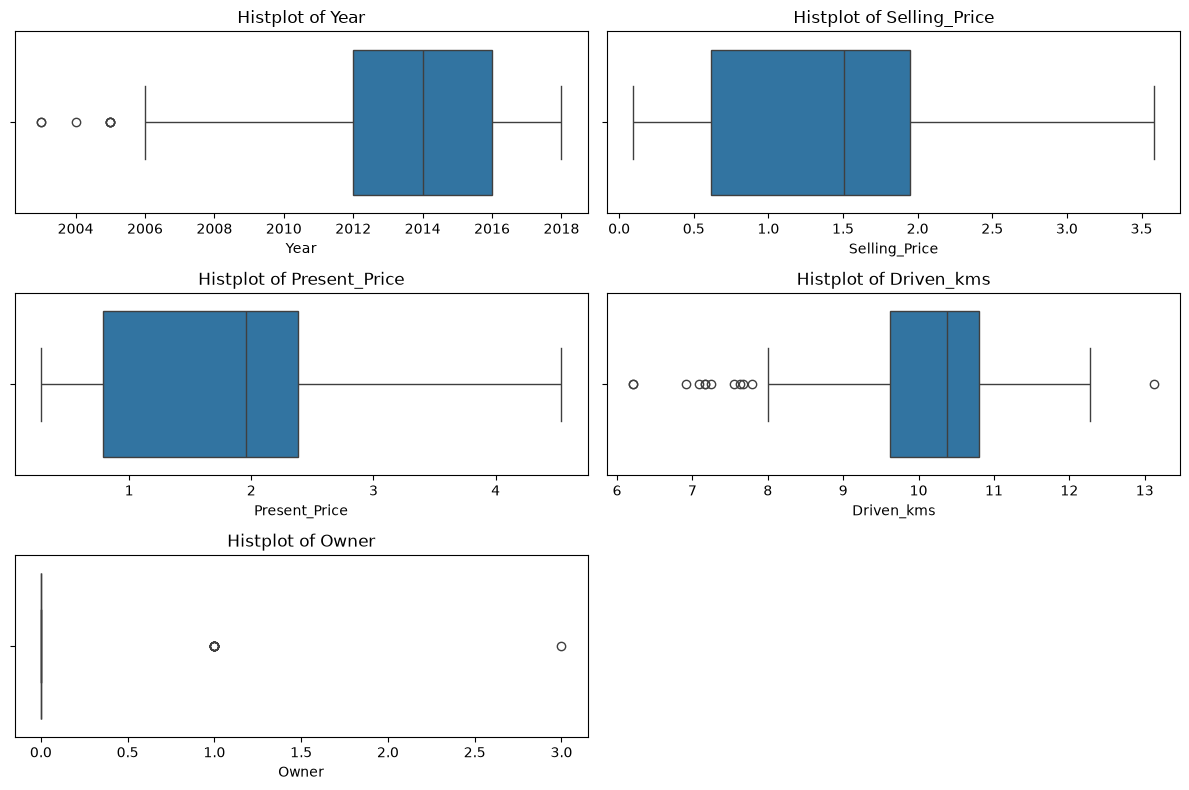

In [340]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()  # Convert 2D array to 1D

for i, col in enumerate(Num_cols):
    sns.boxplot(x=col, data=df_copy, ax=axes[i])
    axes[i].set_title(f"Histplot of {col}")
    
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [341]:
num_cols = ['Year', 'Present_Price', 'Driven_kms']
ohe_cols = ["Fuel_Type", "Selling_type", "Transmission", "Owner"]

In [342]:
X = df_copy.drop(["Selling_Price", "Car_Name"], axis=1)
y = df_copy["Selling_Price"]

In [343]:
X.shape, y.shape

((299, 7), (299,))

In [344]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state= 42 
)

In [345]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((209, 7), (209,), (90, 7), (90,))

In [346]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


processor = ColumnTransformer(
    transformers=(
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
        ('num', StandardScaler(), num_cols)
    )
)

In [347]:
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


models = {
    "LR" : LinearRegression(),
    "RF" : RandomForestRegressor(),
    "DecisionTree" : DecisionTreeRegressor(),
    "XGBoost": XGBRegressor()
}

In [348]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

result =[]
trained_models = {}

for name, model in models.items():
    
    pipeline = Pipeline(
    steps=[
        ('preprocessor', processor),
        ('model', model)
        ]    
    )
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    print(f"Mean R² of {name}:", scores.mean())
    
    pipeline.fit(X_train, y_train)
    
    trained_models[name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred) 
    cv_mean = scores.mean()
    cv_std = scores.std()


    result.append({
        'name': name,
        "r2" : r2,
        "rmse": rmse,
        "mse": mse,
        "cv_mean" : cv_mean,
        "cv_std" : cv_std
    })


Mean R² of LR: 0.9647616437432746
Mean R² of RF: 0.971001990478614
Mean R² of DecisionTree: 0.9618743827517324
Mean R² of XGBoost: 0.9722671824074945


In [349]:
print(pd.DataFrame(result))

           name        r2      rmse       mse   cv_mean    cv_std
0            LR  0.942032  0.197191  0.038884  0.964762  0.008465
1            RF  0.817798  0.349599  0.122219  0.971002  0.008664
2  DecisionTree  0.703091  0.446278  0.199164  0.961874  0.008435
3       XGBoost  0.893424  0.267377  0.071490  0.972267  0.011272


In [350]:
joblib.dump(trained_models['LR'], open("../model/best_model.pkl", "wb"))

In [351]:
bm =joblib.load("../model/best_model.pkl")

In [352]:
type(bm)

sklearn.pipeline.Pipeline

In [ ]:
import pandas as pd

new_data = pd.DataFrame({
    "Year": [2014],
    "Present_Price": [5.59],
    "Driven_kms": [27000],
    "Fuel_Type": ["Petrol"],
    "Selling_type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0]
})
new_data["Driven_kms"] = np.log1p(new_data["Driven_kms"])
new_data["Present_Price"] = np.log1p(new_data["Present_Price"])
prediction = bm.predict(new_data)
prediction = np.expm1(prediction)

print(prediction.round(2))

[3.58]
